# **Simple Buy & Hold Strategy**

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [38]:
data=yf.download("HAL.NS","2020-01-01","2025-12-31")
df=pd.DataFrame(data["Close"]); df.columns=["Price"]
df["LR"]=np.log(df/df.shift(periods=1))
df

/tmp/ipython-input-1771118252.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download("HAL.NS","2020-01-01","2025-12-31")
[*********************100%***********************]  1 of 1 completed


,Price,LR
Date,,
2020-01-01,309.711029,NaN
2020-01-02,311.852875,0.006892
2020-01-03,312.552765,0.002242
2020-01-06,309.414124,-0.010093
2020-01-07,311.704468,0.007375
...,...,...
2025-12-24,4421.299805,0.003149
2025-12-25,4421.299805,0.000000
2025-12-26,4409.200195,-0.002740


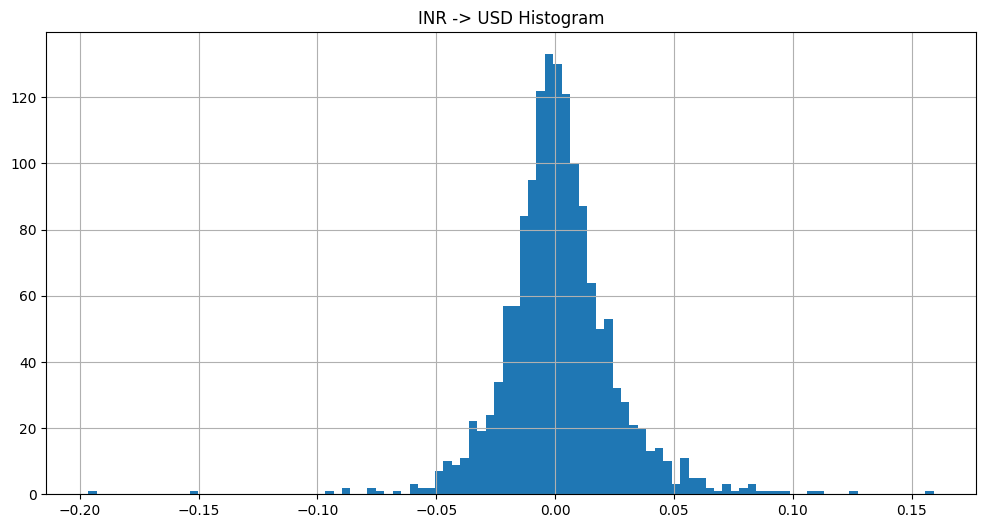

In [39]:
df["LR"].hist(bins=100, figsize=(12,6))
plt.title("HAL.NS Histogram")
plt.show()

Total sum of Log returns

In [40]:
np.exp(df["LR"].sum())

np.float64(13.966244641754448)

<Axes: xlabel='Date'>

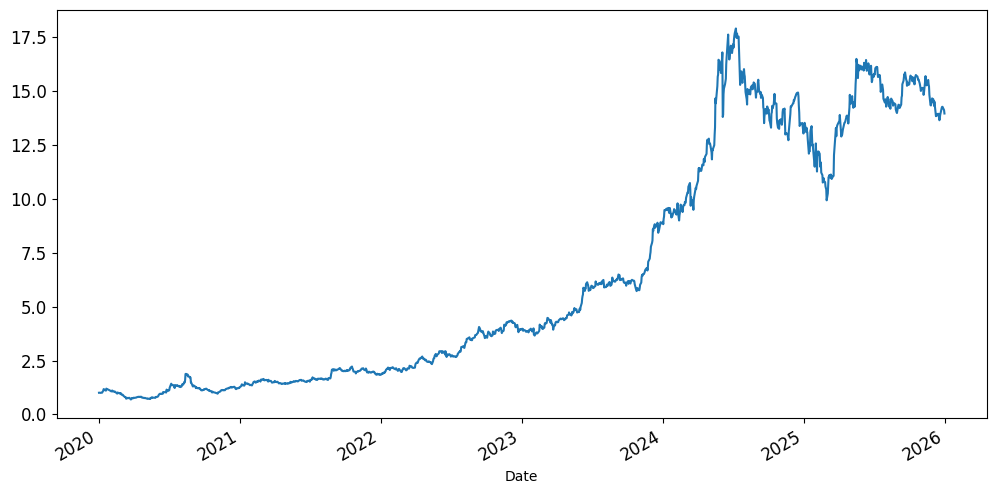

In [49]:
df["C_returns"]=df["LR"].cumsum().apply(np.exp)
df["C_returns"].plot(figsize=(12,6),fontsize=12)

**Annualized Mean Return/Risk**

In [42]:
annual_return=df["LR"].mean()*252
annual_risk=df["LR"].std()*np.sqrt(252)
print(f"Annual Returns = {annual_return:.4f}\nAnnual Risk = {annual_risk:.4f}")

Annual Returns = 0.4468
Annual Risk = 0.3755


**Maximum Price**

<Axes: title={'center': 'HAL.NS Cumulative Maximum'}, xlabel='Date'>

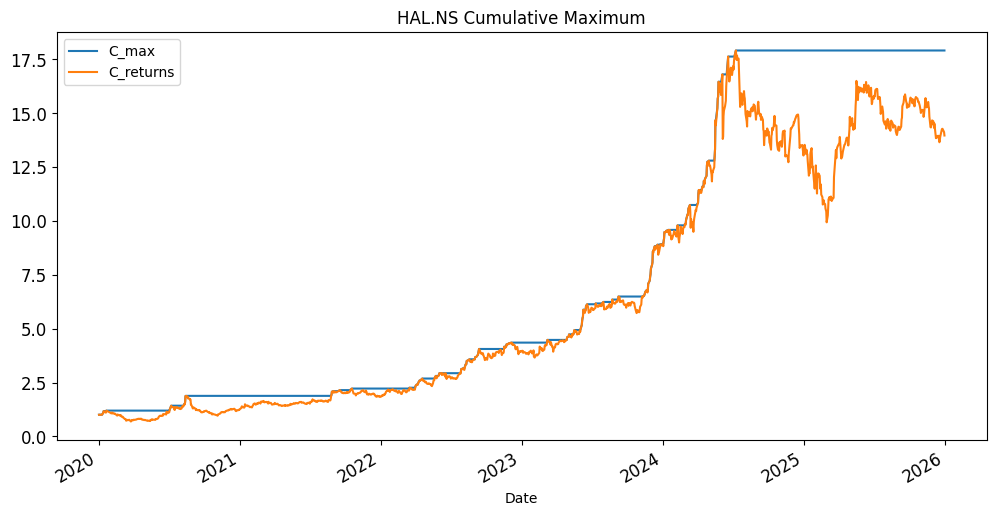

In [45]:
df["C_max"]=df["C_returns"].cummax()
df[["C_max","C_returns"]].plot(figsize=(12,6),fontsize=12, title="HAL.NS Cumulative Maximum")

**Drawdown**
> Drawdown = Max_price - current_price

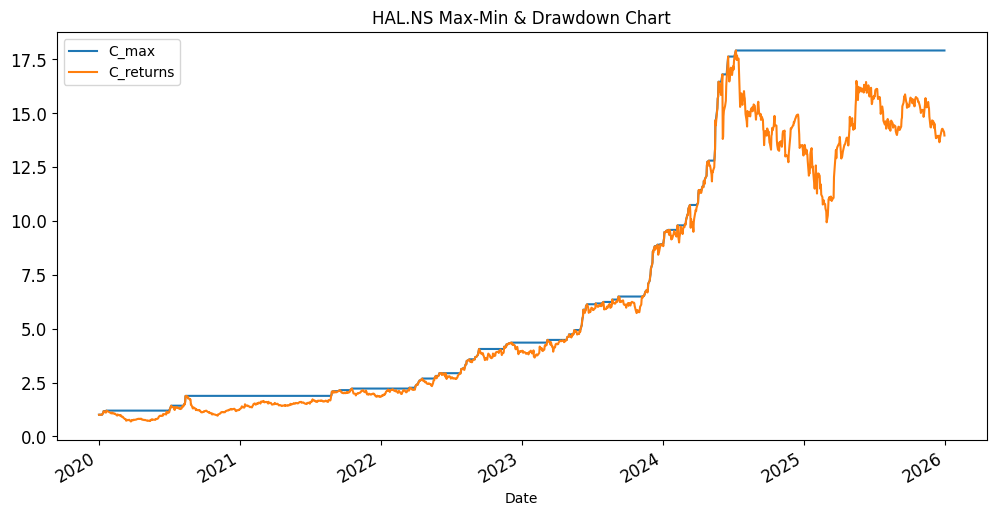

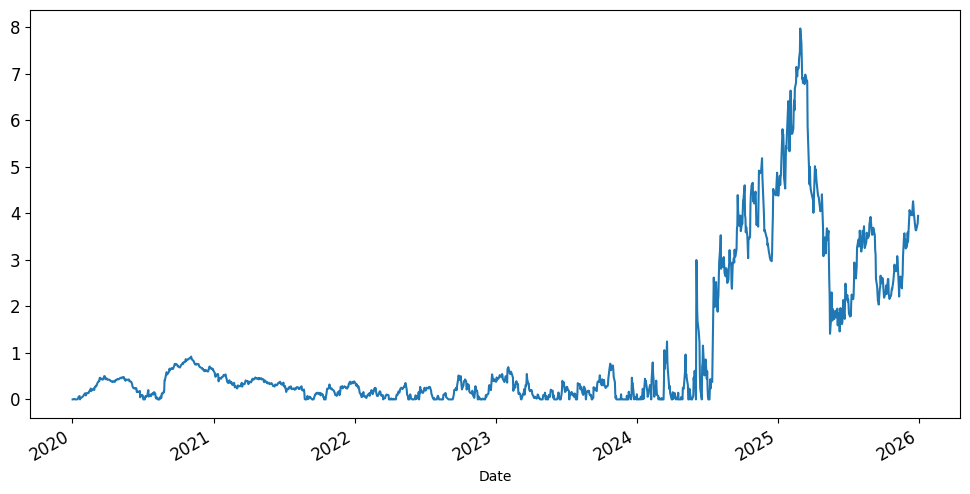

In [46]:
df["Drawdown"]=df["C_max"]-df["C_returns"]
df["Drawdown"].max()
df[['C_max','C_returns']].plot(figsize=(12,6),fontsize=12,title="HAL.NS Max-Min & Drawdown Chart")
plt.show()
df["Drawdown"].plot(figsize=(12,6),fontsize=12)
plt.show()